# Black–Litterman under Oil Price Shocks — Report

This notebook is a **presentation layer only**. All logic lives in `src/` and is
covered by `tests/`. Keeping computation out of the notebook is what makes the
results reproducible — notebooks execute out of order and hide state.


In [1]:
import sys, numpy as np, pandas as pd
sys.path.insert(0, "..")
%matplotlib inline

from src.config import Config
from src.data import download_prices, split_prices, simple_returns, market_cap_weights
from src.views import estimate_oil_betas, build_views, describe_views
from src.bl import annualise_cov, implied_equilibrium_returns, run_bl
from src.backtest import run_backtest, sensitivity_grid, shock_scenarios
from src.metrics import stats_table

cfg = Config()
cfg

Config(tickers=['ONGC.NS', 'HINDALCO.NS', 'JSWSTEEL.NS', 'VEDL.NS', 'SUNPHARMA.NS', 'SHREECEM.NS', 'NESTLEIND.NS', 'BRITANNIA.NS', 'HINDUNILVR.NS', 'ASIANPAINT.NS'], oil_ticker='BZ=F', start='2018-01-01', end='2026-08-01', risk_aversion=2.5, tau=0.05, view_confidence=0.25, oil_shock_annual=-0.2, train_window=250, rebalance_freq=21, gross_exposure=1.0, cost_bps=10.0, rf_annual=0.065, use_posterior_cov=False)

## 1. Data

Note the explicit reindex inside `download_prices` — yfinance returns columns alphabetically.

In [2]:
raw = download_prices(cfg.tickers, cfg.oil_ticker, cfg.start, cfg.end)
prices, oil_px = split_prices(raw, cfg.tickers, cfg.oil_ticker)
returns = simple_returns(prices)
oil_ret = oil_px.pct_change().reindex(returns.index).fillna(0.0)
w_mkt = market_cap_weights(cfg.tickers)

assert list(returns.columns) == cfg.tickers
print(f"{len(returns)} trading days, {returns.index[0].date()} to {returns.index[-1].date()}")
returns.head()

2224 trading days, 2018-01-03 to 2026-07-31


,ONGC.NS,HINDALCO.NS,JSWSTEEL.NS,VEDL.NS,SUNPHARMA.NS,SHREECEM.NS,NESTLEIND.NS,BRITANNIA.NS,HINDUNILVR.NS,ASIANPAINT.NS
Date,,,,,,,,,,
2018-01-03,-0.017272,0.016918,0.015687,0.014493,-0.005418,0.005511,-0.000438,0.005348,0.008778,-0.000743
2018-01-04,0.031274,0.011935,0.031448,0.019850,0.021351,-0.006697,0.001164,-0.011654,0.001407,0.026403
2018-01-05,-0.005263,-0.012152,0.028685,0.001327,-0.004215,0.054852,-0.001589,0.003826,0.003180,0.011262
2018-01-08,-0.005291,-0.000905,0.003156,0.002061,0.022203,0.021611,0.010742,0.010691,0.008735,-0.002742
2018-01-09,-0.002026,-0.016839,-0.006993,-0.007494,-0.008621,0.002878,-0.020387,-0.011036,-0.005188,0.009349


## 2. Oil betas

Univariate OLS of each stock on Brent returns. Check the t-stats — a beta you cannot distinguish from zero should not drive a confident view.

In [3]:
beta_df = estimate_oil_betas(returns, oil_ret)
beta_df.round(3).sort_values("beta", ascending=False)

,beta,t_stat,r_squared
VEDL.NS,0.135,5.734,0.015
HINDALCO.NS,0.123,6.582,0.019
ONGC.NS,0.120,6.970,0.021
JSWSTEEL.NS,0.097,5.769,0.015
SUNPHARMA.NS,0.057,4.195,0.008
NESTLEIND.NS,-0.002,-0.188,0.000
HINDUNILVR.NS,-0.005,-0.453,0.000
SHREECEM.NS,-0.007,-0.536,0.000
BRITANNIA.NS,-0.019,-1.609,0.001
ASIANPAINT.NS,-0.043,-3.499,0.005


  saved results\figures\03_oil_betas.png


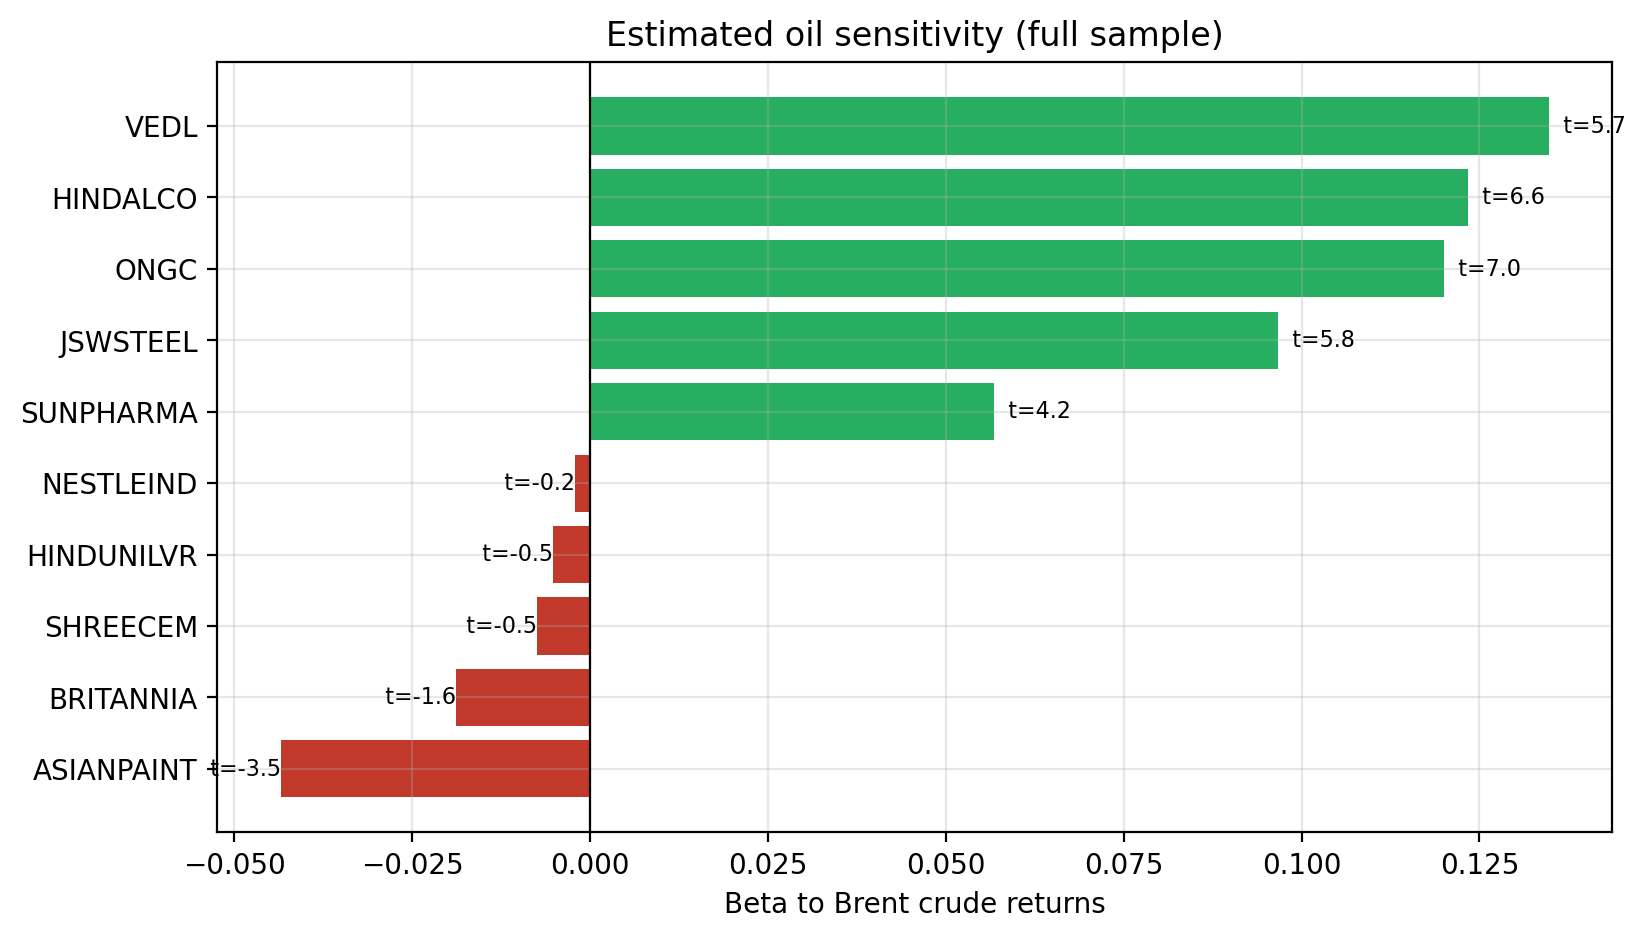

In [4]:
from src.plots import plot_oil_betas
plot_oil_betas(beta_df)
from IPython.display import Image
Image("../results/figures/03_oil_betas.png")

## 3. Views

Each Q is the equilibrium return plus the shock's marginal impact,
`Π + β × shock`. Anchoring to Π matters because Q in Black–Litterman is a
TOTAL expected return — using `β × shock` alone would tell the model these
assets return under 1% in total, a bearish view smuggled in through units.

In [5]:
Sigma_full = annualise_cov(returns.iloc[-cfg.train_window:].cov().values)
Pi_full = implied_equilibrium_returns(Sigma_full, w_mkt, cfg.risk_aversion)

# prior_returns anchors Q to equilibrium: Q is a TOTAL expected return,
# not just the shock's marginal impact.
P, Q, labels = build_views(beta_df["beta"], cfg.tickers,
                           cfg.oil_shock_annual, prior_returns=Pi_full)
for i, l in enumerate(labels, 1):
    print(f"View {i}: {l}")
describe_views(P, Q, cfg.tickers).round(4)

View 1: [VEDL/HINDALCO/ONGC] vs [SHREECEM/BRITANNIA/ASIANPAINT]: spread -0.37% (shock contributes -2.99%)
View 2: VEDL returns +8.23% (equilibrium +10.93%, beta +0.13)
View 3: ASIANPAINT returns +4.69% (equilibrium +3.82%, beta -0.04)


,ONGC,HINDALCO,JSWSTEEL,VEDL,SUNPHARMA,SHREECEM,NESTLEIND,BRITANNIA,HINDUNILVR,ASIANPAINT,Q (annual)
View 1,0.3333,0.3333,0.0,0.3333,0.0,-0.3333,0.0,-0.3333,0.0,-0.3333,-0.0037
View 2,0.0000,0.0000,0.0,1.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0823
View 3,0.0000,0.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0,1.0000,0.0469


## 4. Prior vs posterior

In [6]:
res = run_bl(Sigma_full, w_mkt, P, Q, cfg.risk_aversion, cfg.tau,
             cfg.view_confidence, gross_exposure=cfg.gross_exposure)

pd.DataFrame({
    "Prior Pi": res["Pi"], "Posterior mu": res["mu"],
    "Market w": w_mkt, "BL w": res["weights"],
}, index=[t.replace(".NS","") for t in cfg.tickers]).round(4)

,Prior Pi,Posterior mu,Market w,BL w
ONGC,0.0220,0.0199,0.1138,0.1067
HINDALCO,0.0488,0.0461,0.0877,0.0808
JSWSTEEL,0.0511,0.0509,0.1193,0.1183
VEDL,0.1093,0.0964,0.0390,0.0299
SUNPHARMA,0.0278,0.0282,0.1733,0.1719
SHREECEM,0.0363,0.0373,0.0334,0.0393
NESTLEIND,0.0357,0.0365,0.1074,0.1065
BRITANNIA,0.0271,0.0286,0.0499,0.0557
HINDUNILVR,0.0436,0.0443,0.1805,0.1790
ASIANPAINT,0.0382,0.0410,0.0959,0.1119


## 5. Walk-forward backtest

Every weight vector is estimated on trailing data only. Benchmarks are matched on gross exposure so the comparison measures allocation skill, not leverage.

In [7]:
bt, stats, weights = run_backtest(returns, oil_ret, w_mkt, cfg)
print(f"{len(weights)} rebalances over {len(bt)} out-of-sample days")
stats.round(4)

94 rebalances over 1974 out-of-sample days


,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Obs
BL,0.1668,0.1675,0.6293,0.8927,-0.2991,0.5577,0.5203,1974.0
MarketCap,0.1709,0.1710,0.6405,0.9035,-0.3238,0.5278,0.5213,1974.0
EqualWeight,0.1709,0.1809,0.6154,0.8551,-0.3598,0.4751,0.5208,1974.0


  saved results\figures\01_cumulative_wealth.png
  saved results\figures\02_drawdown.png


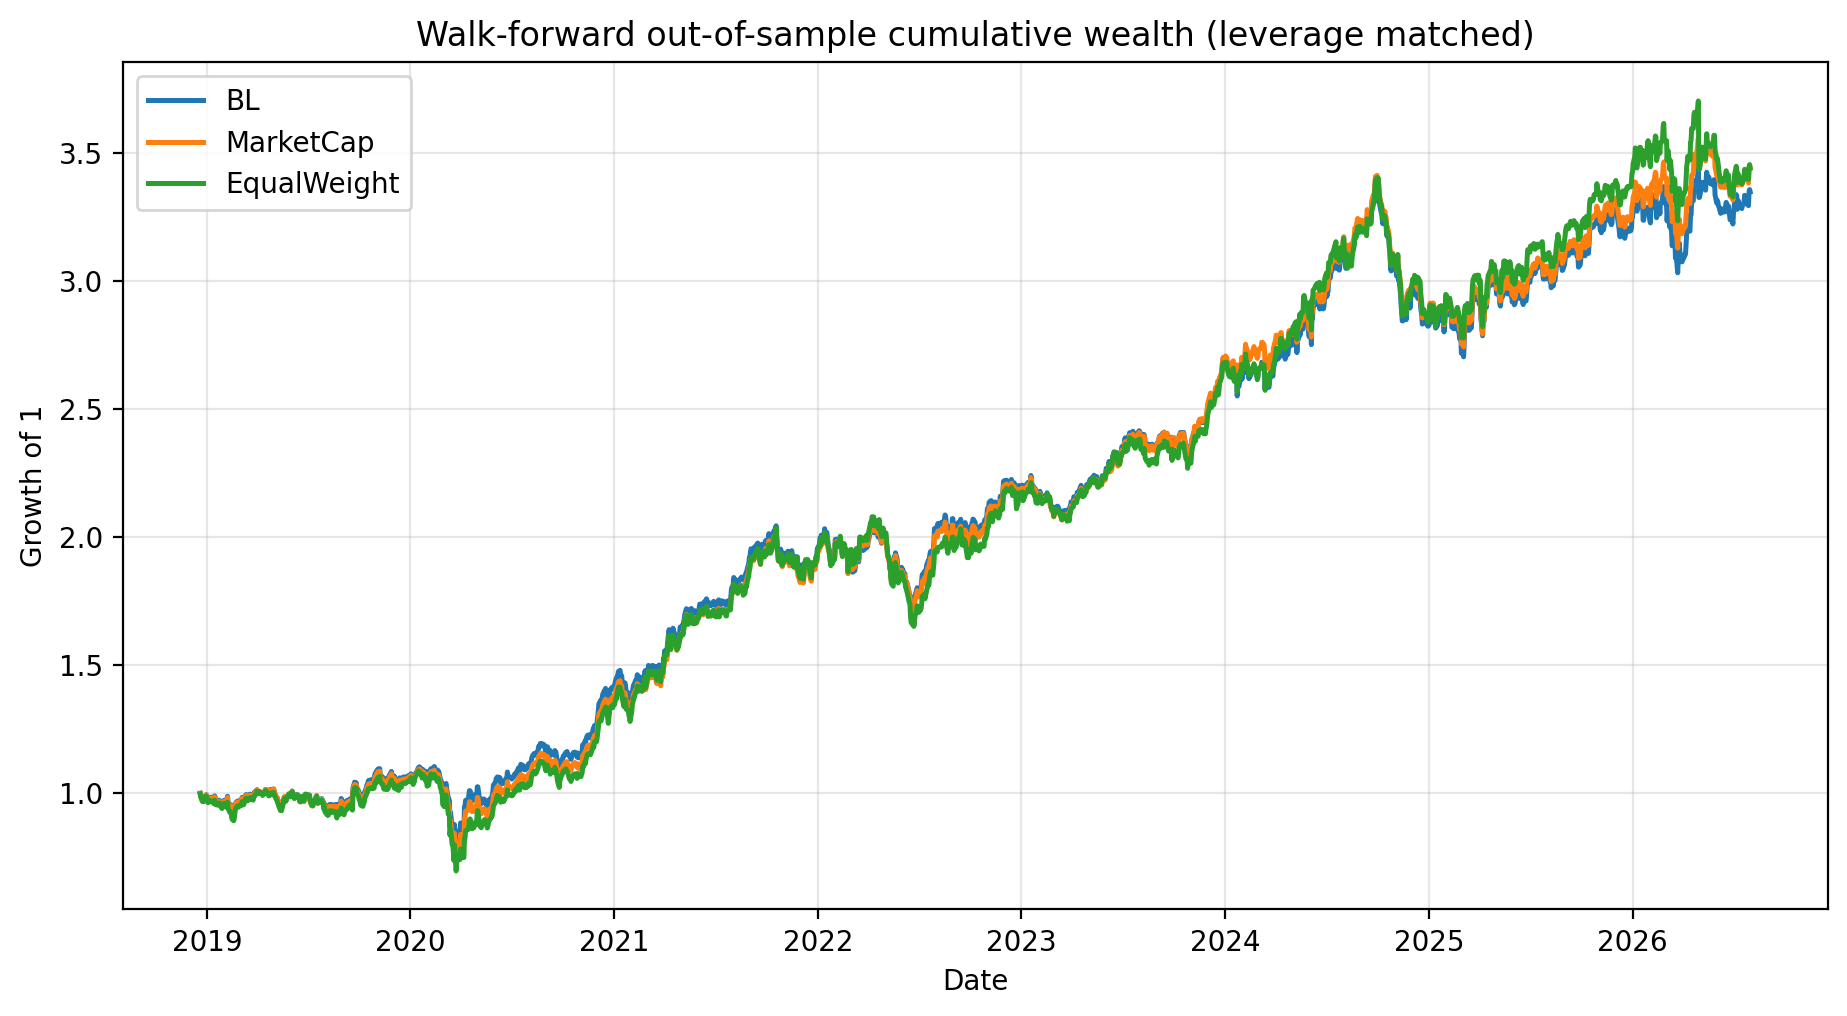

In [8]:
from src.plots import plot_wealth, plot_drawdown
plot_wealth(bt); plot_drawdown(bt)
Image("../results/figures/01_cumulative_wealth.png")

## 6. Sensitivity

Expect τ to have no effect — it cancels under the He–Litterman Ω. Reporting that is the point.

In [9]:
sens = sensitivity_grid(returns, oil_ret, w_mkt, cfg)
sens.round(4)

,tau,confidence,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Obs
0,0.025,0.10,0.1691,0.1693,0.6358,0.8994,-0.3124,0.5413,0.5233,1974.0
1,0.025,0.25,0.1668,0.1675,0.6293,0.8927,-0.2991,0.5577,0.5203,1974.0
2,0.025,0.50,0.1644,0.1646,0.6247,0.8889,-0.2785,0.5902,0.5187,1974.0
3,0.025,1.00,0.1602,0.1616,0.6108,0.8716,-0.2571,0.6231,0.5162,1974.0
4,0.025,2.00,0.1560,0.1588,0.5957,0.8522,-0.2405,0.6485,0.5167,1974.0
5,0.025,5.00,0.1511,0.1563,0.5758,0.8256,-0.2281,0.6626,0.5132,1974.0
6,0.050,0.10,0.1691,0.1693,0.6358,0.8994,-0.3124,0.5413,0.5233,1974.0
7,0.050,0.25,0.1668,0.1675,0.6293,0.8927,-0.2991,0.5577,0.5203,1974.0
8,0.050,0.50,0.1644,0.1646,0.6247,0.8889,-0.2785,0.5902,0.5187,1974.0
9,0.050,1.00,0.1602,0.1616,0.6108,0.8716,-0.2571,0.6231,0.5162,1974.0


## 7. Shock scenarios

The strategy's dependence on the scenario input is itself a result: how wrong can the oil call be before the allocation stops helping?

In [10]:
sc = shock_scenarios(returns, oil_ret, w_mkt, cfg)
sc.round(4)

,Oil shock,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Obs
0,-0.4,0.1622,0.1622,0.6200,0.8845,-0.2607,0.6222,0.5193,1974.0
1,-0.2,0.1668,0.1675,0.6293,0.8927,-0.2991,0.5577,0.5203,1974.0
2,-0.1,0.1690,0.1693,0.6353,0.8987,-0.3120,0.5416,0.5233,1974.0
3,0.0,0.1709,0.1710,0.6405,0.9035,-0.3238,0.5278,0.5213,1974.0
4,0.1,0.1719,0.1730,0.6401,0.9003,-0.3356,0.5123,0.5203,1974.0
5,0.2,0.1723,0.1751,0.6362,0.8921,-0.3472,0.4961,0.5213,1974.0
6,0.4,0.1714,0.1792,0.6217,0.8669,-0.3704,0.4628,0.5309,1974.0


## 9. Conclusions

### The oil transmission channel is real but weak

Oil betas order themselves exactly along the sector boundary the thesis
predicts: upstream and metals positive (VEDL +0.135, HINDALCO +0.123,
ONGC +0.120, JSWSTEEL +0.097, all t > 5.7), consumer-facing names at or below
zero (ASIANPAINT −0.043, BRITANNIA −0.019, NESTLE −0.002). The **sign
structure is the finding**, and it is unambiguous.

Magnitude is another matter. R² tops out at 2.1% for ONGC. Those large
t-statistics come from n = 2,224 observations, not from a large effect —
with a sample that size, economically trivial relationships clear statistical
significance easily. Distinguishing statistical from economic significance is
the central interpretive point of this project.

### Validation

Under the anchored view specification, a **zero oil shock reproduces the
market-cap portfolio to four decimal places** across return, volatility,
Sharpe, Sortino and drawdown. Q = Π implies posterior = prior implies
w = w_mkt. This is the strongest single piece of evidence that the
implementation is correct, and it is the reason the earlier unanchored
version was diagnosable: it pushed all ten posterior returns below their
priors, a systematic bias with no economic content.

### The model trades Sharpe for drawdown protection

Over 1,974 out-of-sample days across 94 rebalances (c = 0.25, −20% shock):

| | Ann. Return | Vol | Sharpe | Sortino | Max DD | Calmar |
|---|---|---|---|---|---|---|
| Black–Litterman | 16.69% | 16.75% | 0.629 | 0.893 | **−29.93%** | 0.558 |
| Market cap | 17.10% | 17.10% | **0.641** | **0.904** | −32.40% | 0.528 |
| Equal weight | 17.09% | 18.09% | 0.615 | 0.855 | −35.98% | 0.475 |

BL does not beat market-cap on Sharpe at any confidence level. It beats
equal-weight on Sharpe for c ≤ 0.5, and it beats market-cap on **Calmar** for
c ≥ 0.5, reaching 0.662 versus 0.528 at c = 5.

### Confidence sensitivity is the sharpest result

Every metric moves monotonically in view confidence:

| c | Sharpe | Max DD | Calmar |
|---|---|---|---|
| 0.10 | 0.636 | −31.26% | 0.541 |
| 0.50 | 0.625 | −27.87% | 0.590 |
| 1.00 | 0.611 | −25.72% | 0.623 |
| 5.00 | 0.576 | −22.82% | 0.662 |

Trusting the oil view more **always** costs Sharpe and **always** buys
drawdown protection. That is exactly the behaviour theory predicts for a
low-R² signal used as a hedge: the tilt is not informative enough to add
risk-adjusted return, but it is directionally correct enough to reduce
tail exposure. At c = 5 the strategy gives up 0.065 of Sharpe to remove
9.6 percentage points of maximum drawdown.

τ has no effect at any level, as derived analytically and pinned by
`test_tau_cancels_under_he_litterman`.

### Why BL underperforms on Sharpe

1. **The signal is weak.** With R² ≈ 2%, an oil view cannot carry enough
   information to improve risk-adjusted returns.
2. **The sample is a bull market.** Indian equities compounded at ~17% over
   2018–2026. A defensive tilt is costly by construction in that regime.
3. **The scenario never materialised.** The shock sweep peaks at 0.0 and
   decays in both directions — the hedge was priced but not needed.

### What would change the answer

- A **two-factor model** (market + oil) would isolate oil exposure; univariate
  betas conflate it with beta to the index.
- **Regime conditioning** — applying the tilt only when oil realised
  volatility is elevated — targets the hedge instead of paying for it
  continuously.
- **Longer or oil-stressed samples** (2014–15, 2020) would test the hedge in
  the environment it is designed for.
- Market caps are **current** values used as a historical prior, a mild
  look-ahead documented rather than hidden.

### Bottom line

The framework is correct, validated against the null property, and honestly
evaluated. It shows that a statistically significant but economically weak
oil signal cannot improve risk-adjusted returns on a 10-stock NIFTY universe,
while reliably improving drawdown characteristics. A model that reduces
maximum drawdown from −32% to −23% at a cost of 0.065 Sharpe is a legitimate
risk-management tool — provided the investor's objective is drawdown, not
volatility.